# Gradient Descent

Gradient Descent is a method used to find local minima of a function $f$

It's simple- Only uses derivated of f

It's slow

Today: Linear Regression with Gradient Descent
- This is not really needed here, it's just an example. We have a closed-form formula for $\theta$.


Next Week: Logistic and Softmax regression

Adding momentum will help speed up the algorithm.
****

### How does it work? Here are some helper gradients:

$$\nabla (x^Ty) = y$$

$$\nabla (x^TMx) = 2Mx$$


## Linear Regression

$$f(\theta) = \|y=X\theta\|^2$ = (y-X\theta)^T(y-X\theta) = y^Ty-y^TX\theta -\theta^TX^Ty+\theta^TX^TX\theta$$

Recall that $y^TX\theta =\theta^TX^Ty$ and $X^TX$ is symmetric. So we can write the above as:

$$f(\theta)= y^Ty - 2\theta^TX^Ty +\theta^TX^TX\theta$$

Then we calculate the gradient of $f$ as follows:

$$\nabla f = 0-2X^Ty + 2X^TX\theta = 2X^TX\theta - 2X^Ty = 2X^T(X\theta - y)$$
****

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

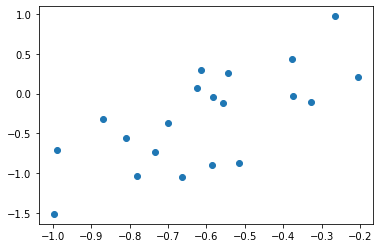

In [2]:
# Let us generate a linear looking dataset
m = 20
x = -1 + np.random.rand(m)
y = 2*x+1 +0.5*np.random.randn(m)
plt.scatter(x,y)

In [3]:
X = np.ones((m,2))
X[:,1] = x

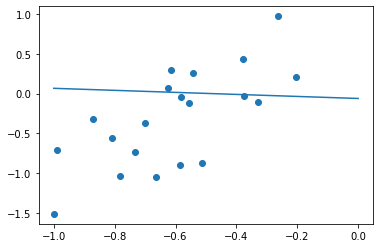

In [4]:
# initial theta
theta = np.random.randn(2)

# plot "fitted" line

m_plot = 100
x_plot = np.linspace(-1,0,m_plot)
X_plot = np.ones((m_plot,2))
X_plot[:,1] = x_plot

y_plot = X_plot.dot(theta)

plt.scatter(x,y)
plt.plot(x_plot,y_plot)

In [5]:
# learning rate: chosen by us
lr = 0.01

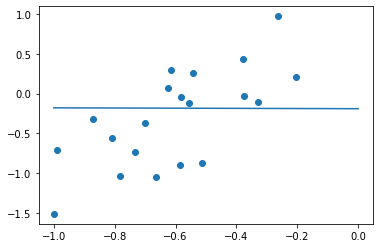

In [6]:
# gradient descent iteration
gradient = 2*X.T.dot(X.dot(theta)-y)
theta = theta - lr*gradient

y_plot = X_plot.dot(theta)

plt.scatter(x,y)
plt.plot(x_plot,y_plot)


In [7]:
from my_functions import linregression_GD

In [8]:
theta, mse = linregression_GD(X,y,lr,1000)

In [9]:
theta

array([0.8621143 , 1.92775427])

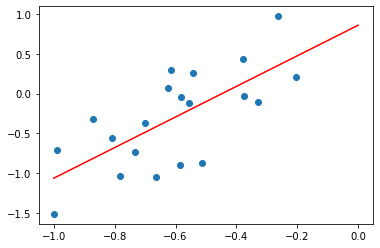

In [10]:
plt.scatter(x,y)

m_plot = 200
x_plot = np.linspace(-1,0,m_plot)
y_plot = x_plot*theta[1]+theta[0]

plt.plot(x_plot,y_plot, color = 'red')

## Early Stopping

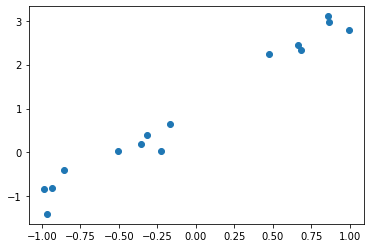

In [11]:
m = 15
x = -1 + 2*np.random.rand(m)
y = 2*x+1+0.25*np.random.randn(m)
plt.scatter(x,y)

In [12]:
# training / testing split

x_train, y_train = x[0:3*m//4],y[0:3*m//4]
x_test, y_test = x[3*m//4:m],y[3*m//4:m]

In [13]:
from my_functions import build_poly_features

In [14]:
# fit a degree-d polynomial

d = len(x_train) # this will pass through all the training points
X_train = build_poly_features(x_train, degree=d)
X_test = build_poly_features(x_test,degree=d)


# no gradient descent
theta = np.linalg.lstsq(X_train,y_train, rcond=None)[0]

mse_train: 7.541122060847013e-27
mse_test: 185.84159081997655


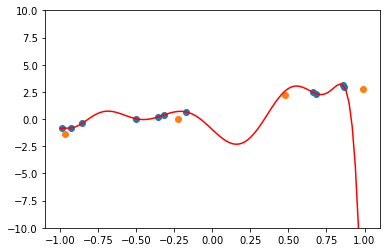

In [15]:
plt.scatter(x_train,y_train)
plt.scatter(x_test,y_test)

m_plot = 100
x_plot = np.linspace(-1,1,m_plot)
X_plot = build_poly_features(x_plot,degree=d)
y_plot = X_plot.dot(theta)
plt.plot(x_plot,y_plot,color='red')
plt.ylim([-10,10])

mse_train = np.mean((y_train - X_train.dot(theta))**2)
mse_test = np.mean((y_test - X_test.dot(theta))**2)
print('mse_train:',mse_train)
print('mse_test:',mse_test)

In [23]:
# now with gradient descent:

theta,mse,mse_test = linregression_GD(X_train, y_train,
                                      learning_rate=0.1,
                                      epochs=100,
                                      testing_data=(X_test,y_test))

mse_train: 6.693524100689781e+105
mse_test: 7.522791560206111e+105


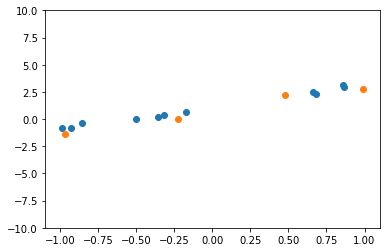

In [24]:
plt.scatter(x_train,y_train)
plt.scatter(x_test,y_test)

m_plot = 100
x_plot = np.linspace(-1,1,m_plot)
X_plot = build_poly_features(x_plot,degree=d)
y_plot = X_plot.dot(theta)
plt.plot(x_plot,y_plot,color='red')
plt.ylim([-10,10])

mse_train = np.mean((y_train - X_train.dot(theta))**2)
mse_test = np.mean((y_test - X_test.dot(theta))**2)
print('mse_train:',mse_train)
print('mse_test:',mse_test)